# Malaria Cases in the United States - Exploratory Data Analysis
### State and County-Level Distribution | 2016 vs. 2017

**Author:** Dr. Maria Julia Judson, DVM, MSc  
**Data Source:** CDC - Number of Reported Malaria Cases by County, United States (2016 & 2017)  
**Tools:** Python (pandas, matplotlib, numpy)

---

## Project Overview

Malaria cases reported in the United States are almost exclusively travel-associated, making their geographic distribution a reflection of international travel patterns and access to healthcare. This analysis uses CDC county-level surveillance data to identify which states and counties reported the highest malaria burden in 2016 and 2017, and quantifies year-over-year changes in reported cases.

**Objectives:**
1. Identify states and counties with the highest reported malaria burden;
2. Compare disease distribution between 2016 and 2017;
3. Quantify absolute and relative year-over-year changes at the state and county level;
4. Flag data quality considerations (missing states/counties across years).

---
## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

---
## 2. Load & Prepare Data

In [7]:
# Load raw CDC datasets
df2016 = pd.read_csv("Number_of_Reported_Malaria_Cases_by_County—_United_States,_2016_20260508.csv")
df2017 = pd.read_csv("Number_of_Reported_Malaria_Cases_by_County—_United_States,_2017_20260508.csv")

# Standardize case column names and add year
df2016 = df2016.rename(columns={"MAL_FREQ_2016": "cases"})
df2017 = df2017.rename(columns={"MAL_FREQ_2017": "cases"})
df2016["year"] = 2016
df2017["year"] = 2017

# Combine into single dataset
combined = pd.concat([df2016, df2017], ignore_index=True)

print(f"2016: {df2016.shape[0]} positive county records | {df2016['STATE'].nunique()} states")
print(f"2017: {df2017.shape[0]} positive county records | {df2017['STATE'].nunique()} states")
print(f"Combined: {combined.shape[0]} positive county records")

2016: 98 positive county records | 32 states
2017: 97 positive county records | 29 states
Combined: 195 positive county records


---
## 3. Data Quality — Coverage Check

Before comparing years, we verify which states appear in both datasets. States present in only one year are excluded from year-over-year comparisons to avoid misleading results.

In [5]:
states_2016 = set(df2016["STATE"].dropna())
states_2017 = set(df2017["STATE"].dropna())

missing_in_2017 = states_2016 - states_2017
missing_in_2016 = states_2017 - states_2016
common_states = states_2016.intersection(states_2017)

print(f"States in 2016 only: {missing_in_2017 or 'None'}")
print(f"States in 2017 only: {missing_in_2016 or 'None'}")
print(f"States present in both years: {len(common_states)}")

# Positive counties only
positive_2016 = df2016[df2016["cases"] > 0]
positive_2017 = df2017[df2017["cases"] > 0]
print(f"\nCounties with ≥1 case — 2016: {len(positive_2016)} | 2017: {len(positive_2017)}")

States in 2016 only: {'VERMONT', 'KENTUCKY', 'NEVADA', 'WISCONSIN', 'TENNESSEE', 'DELAWARE', 'CALIFORNIA'}
States in 2017 only: {'WASHINGTON', 'SOUTH DAKOTA', 'NORTH DAKOTA', 'IOWA'}
States present in both years: 25

Counties with ≥1 case — 2016: 98 | 2017: 97


---
## 4. State-Level Analysis

In [6]:
# Aggregate by state and year — common states only
summary_state = combined.groupby(["STATE", "year"])["cases"].sum().reset_index()
summary_state_filtered = summary_state[summary_state["STATE"].isin(common_states)]

# Pivot for side-by-side comparison
state_pivot = summary_state_filtered.pivot_table(
    index="STATE", columns="year", values="cases", fill_value=0
).reset_index()

# Year-over-year metrics
state_pivot["change"] = state_pivot[2017] - state_pivot[2016]
state_pivot["pct_change"] = np.where(
    state_pivot[2016] == 0,
    np.where(state_pivot[2017] > 0, np.inf, 0),
    ((state_pivot[2017] - state_pivot[2016]) / state_pivot[2016]) * 100
)

print(f"Total cases 2016: {state_pivot[2016].sum():,.0f}")
print(f"Total cases 2017: {state_pivot[2017].sum():,.0f}")
print(f"National change:  {state_pivot['change'].sum():+,.0f} cases")

Total cases 2016: 1,273
Total cases 2017: 1,370
National change:  +97 cases


### Top 10 States - 2016 vs. 2017

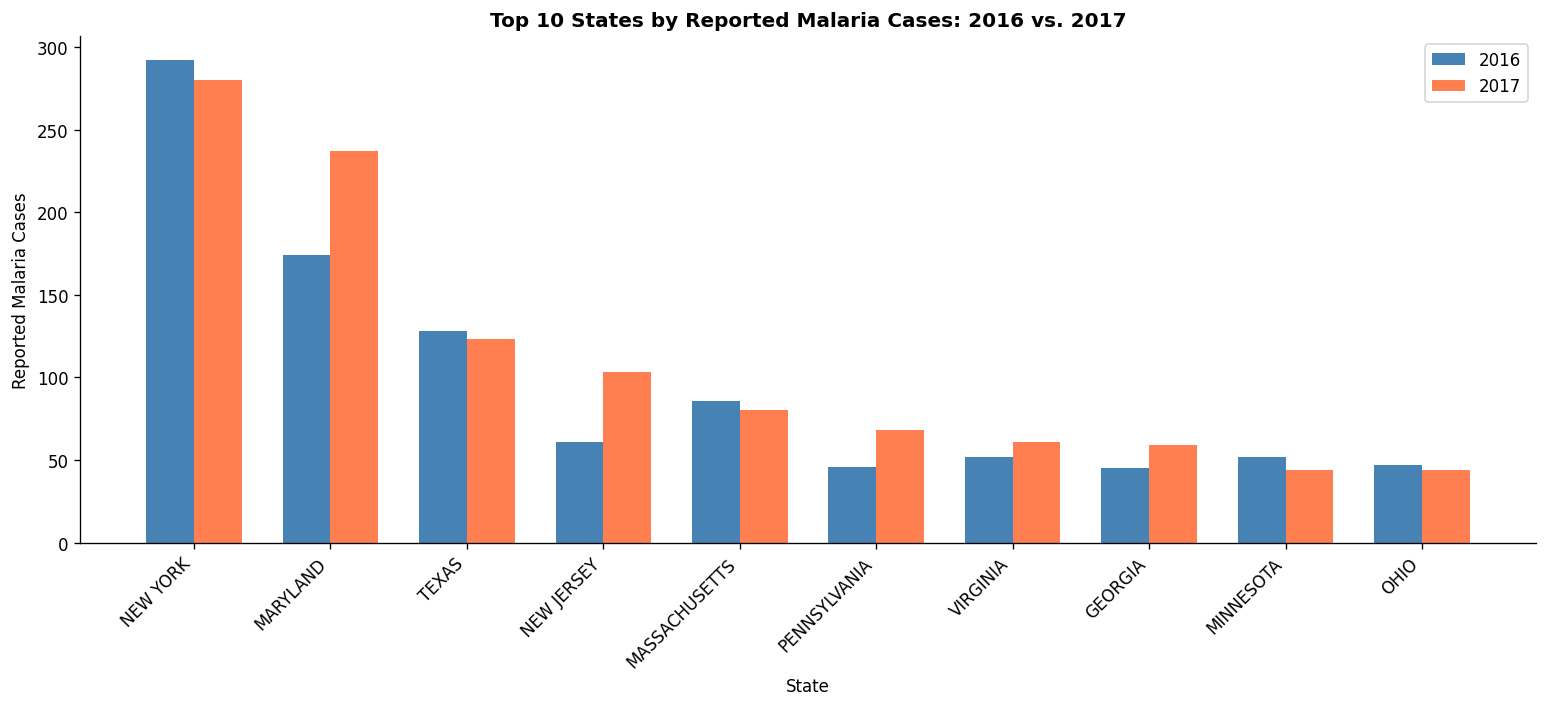

In [8]:
top10_states = state_pivot.sort_values(by=2017, ascending=False).head(10)

x = np.arange(len(top10_states))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))

ax.bar(x - width/2, top10_states[2016], width, label="2016", color="steelblue")
ax.bar(x + width/2, top10_states[2017], width, label="2017", color="coral")

ax.set_xticks(x)
ax.set_xticklabels(top10_states["STATE"], rotation=45, ha="right")
ax.set_xlabel("State")
ax.set_ylabel("Reported Malaria Cases")
ax.set_title("Top 10 States by Reported Malaria Cases: 2016 vs. 2017", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.show()

**Observation:** This graph shows that a small number of states consistently account for the majority of reported malaria cases, suggesting concentrated urban populations with high volumes of international travel and stronger diagnostic and reporting infrastructure. Compare 2016 and 2017 bars to spot which states saw notable shifts.

### Year-over-Year Change by State (Absolute)

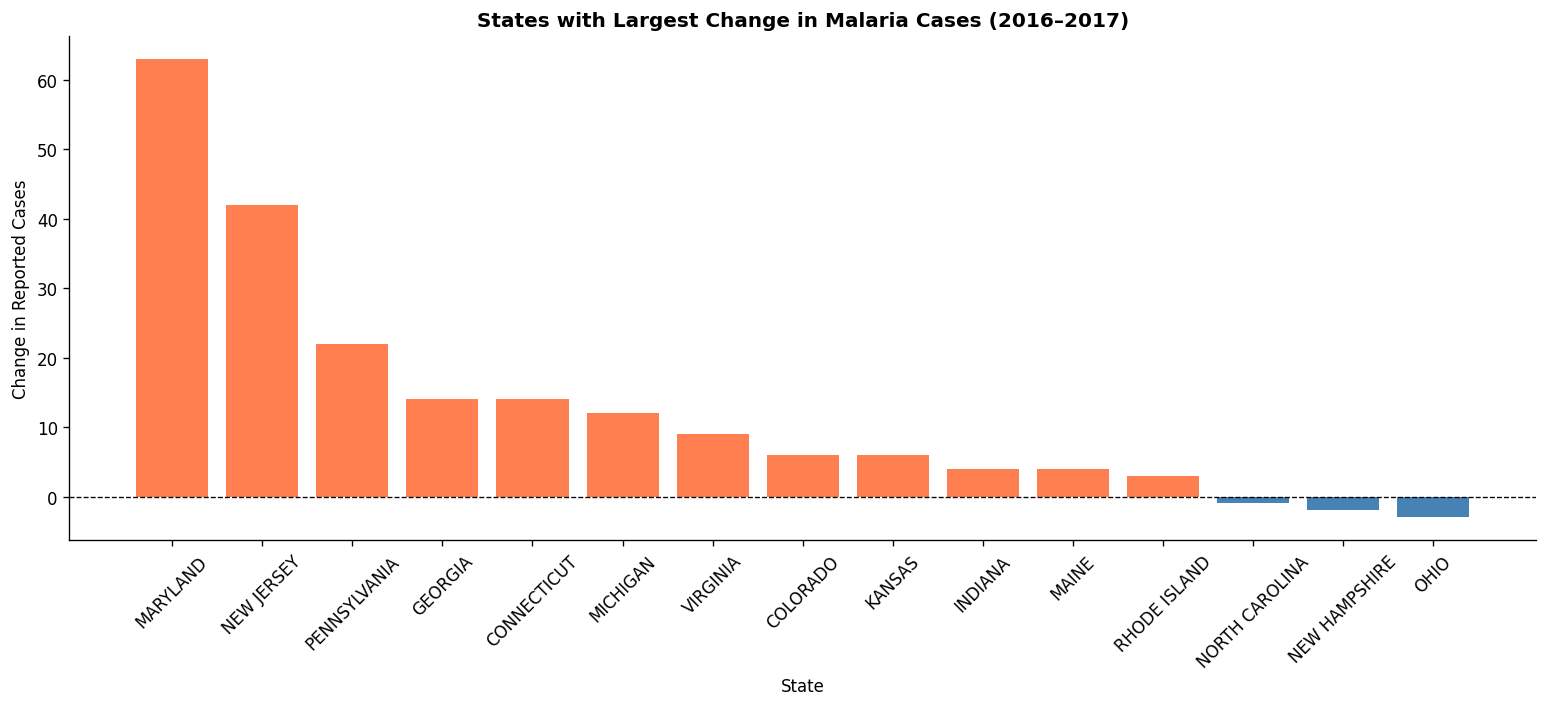

In [9]:
change_sorted = state_pivot.sort_values(by="change", ascending=False).head(15)

colors = ["coral" if c > 0 else "steelblue" for c in change_sorted["change"]]

fig, ax = plt.subplots(figsize=(13, 6))

ax.bar(change_sorted["STATE"], change_sorted["change"], color=colors)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

ax.set_xlabel("State")
ax.set_ylabel("Change in Malaria Reported Cases")
ax.set_title("States with Largest Change in Malaria Cases (2016–2017)", fontweight="bold")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Observation:** Orange bars indicate increases; blue bars indicate decreases. This chart separates states with growing burden from those with declining or stable case counts,a more actionable view than ranking by total cases alone.

### Year-over-Year Change by State (Relative %)

Percentage change highlights states with significant relative increases, even if their absolute numbers are small. States with 0 cases in 2016 and >0 in 2017 are flagged separately as new reporters.

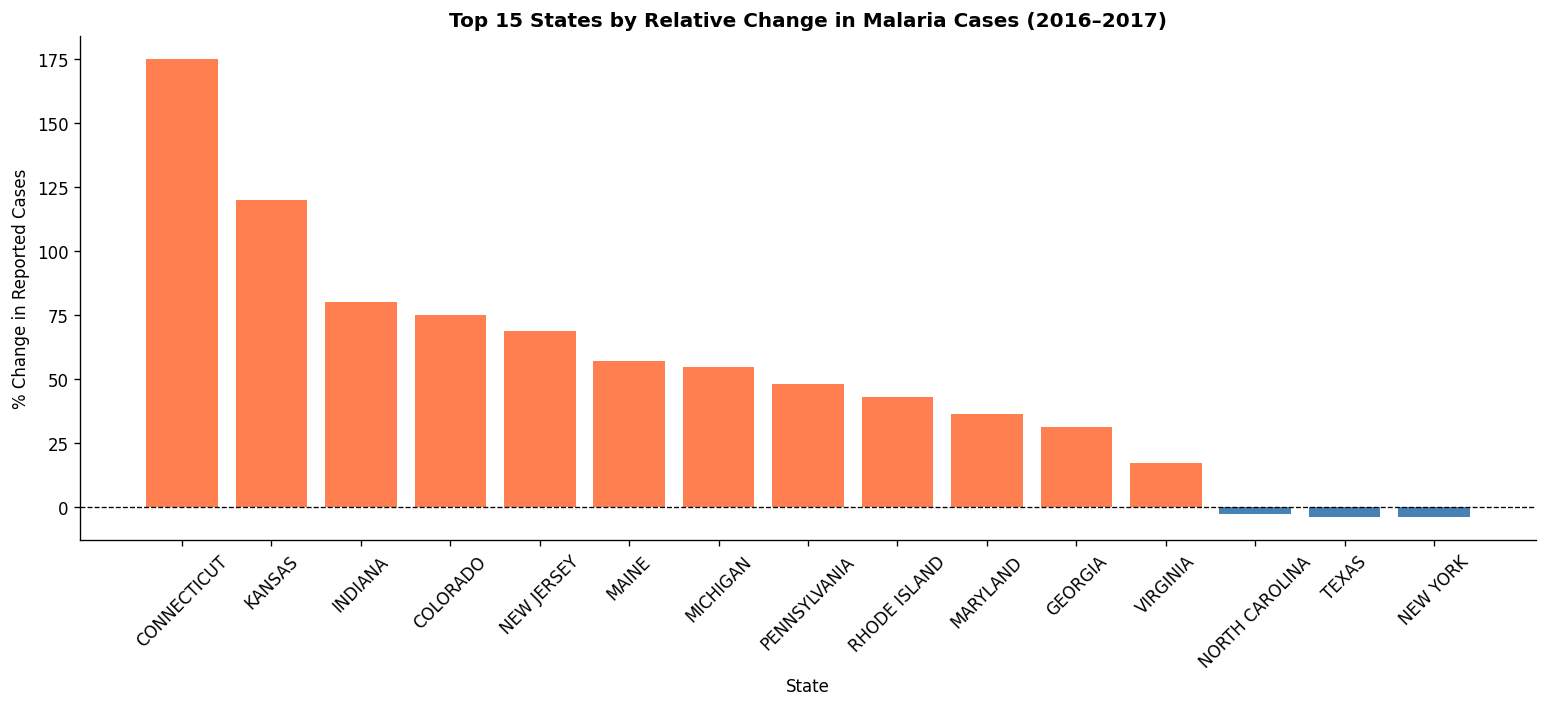

In [15]:
# Exclude infinite values (new reporters) for cleaner chart
pct_finite = state_pivot[state_pivot["pct_change"] != np.inf].sort_values(
    by="pct_change", ascending=False
).head(15)

new_reporters = state_pivot[state_pivot["pct_change"] == np.inf]

colors = ["coral" if p > 0 else "steelblue" for p in pct_finite["pct_change"]]

fig, ax = plt.subplots(figsize=(13, 6))

ax.bar(pct_finite["STATE"], pct_finite["pct_change"], color=colors)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

ax.set_xlabel("State")
ax.set_ylabel("% Change in Reported Cases")
ax.set_title("Top 15 States by Relative Change in Malaria Cases (2016–2017)", fontweight="bold")
ax.tick_params(axis="x", rotation=45)

if not new_reporters.empty:
    states_list = ", ".join(new_reporters["STATE"].tolist())
    ax.annotate(f"New reporters (0→1+ cases): {states_list}",
                xy=(0.01, 0.97), xycoords="axes fraction",
                fontsize=8, color="gray", va="top")

plt.tight_layout()
plt.show()

**Observation:** Relative change can tell a different story than absolute change. A state with few cases but a 200% increase warrants attention as it may signal emerging clusters or improved reporting infrastructure.

---
## 5. County-Level Analysis

In [20]:
# Aggregate by county
summary_county = combined.groupby(["STATE", "COUNTY", "FIPS", "year"])["cases"].sum().reset_index()

county_pivot = summary_county.pivot_table(
    index=["STATE", "COUNTY", "FIPS"],
    columns="year",
    values="cases",
    fill_value=0
).reset_index()

county_pivot["change"] = county_pivot[2017] - county_pivot[2016]

### Top US 10 Counties - 2016 vs. 2017

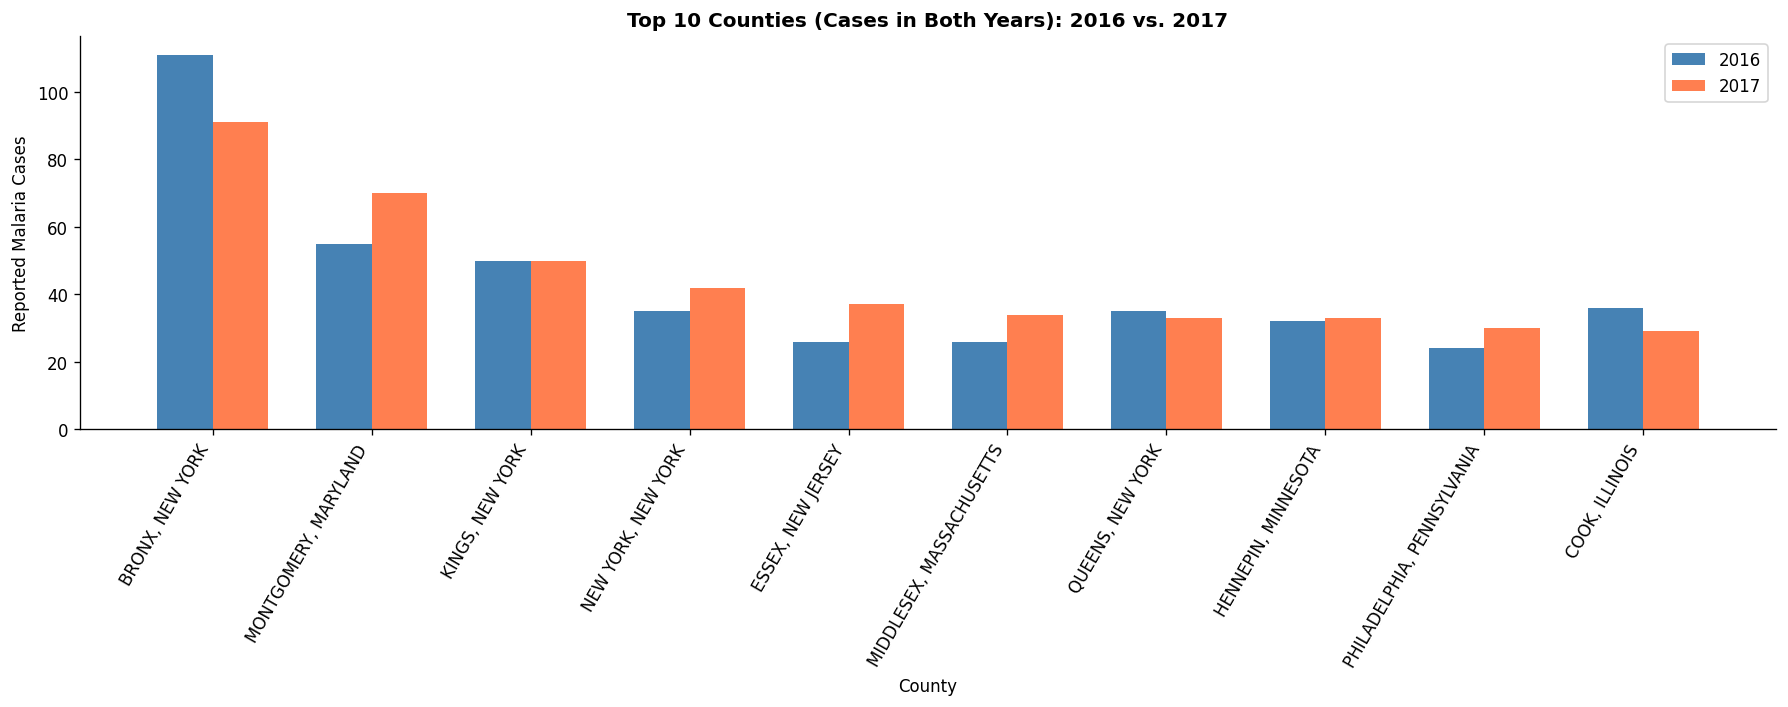

In [22]:
filtered_county_pivot = county_pivot[(county_pivot[2016] > 0) & (county_pivot[2017] > 0)]
top10_counties = filtered_county_pivot.sort_values(by=2017, ascending=False).head(10)
county_labels = top10_counties["COUNTY"] + ", " + top10_counties["STATE"]

x = np.arange(len(top10_counties))
width = 0.35

fig, ax = plt.subplots(figsize=(15, 6))

ax.bar(x - width/2, top10_counties[2016], width, label="2016", color="steelblue")
ax.bar(x + width/2, top10_counties[2017], width, label="2017", color="coral")

ax.set_xticks(x)
ax.set_xticklabels(county_labels, rotation=60, ha="right")
ax.set_xlabel("County")
ax.set_ylabel("Reported Malaria Cases")
ax.set_title("Top 10 Counties (Cases in Both Years): 2016 vs. 2017", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.show()

**Observation:** County-level data reveals concentration within states. High-burden states often have one or two counties driving the majority of their caseload, consistent with urban centers that serve as major international travel hubs and have greater access to diagnostic services capable of identifying malaria.

---
## 6. Key Insights

| # | Finding |
|---|--------|
| 1 | **Concentrated burden:** A small number of states account for the vast majority of U.S. malaria cases, reflecting geographic clustering around major urban and international travel hubs. |
| 2 | **Year-over-year shift:** Absolute and relative change analysis reveals that states with growing burden are not always the highest-volume states — relative increases in smaller states may signal emerging clusters. |
| 3 | **County-level concentration:** Within high-burden states, cases are further concentrated in specific counties, pointing to localized risk factors rather than statewide spread. |
| 4 | **Data coverage gaps:** Not all states appear in both years, which limits direct year-over-year comparisons. Analysis was restricted to common states to ensure comparability. |
| 5 | **Travel-associated context:** U.S. malaria cases are almost exclusively imported. Geographic patterns likely reflect travel routes, immigration corridors, and access to diagnostic services rather than local transmission. |

---
## 7. Next Steps

- **Normalize by population:** Cases per 100,000 residents would enable fairer interstate comparisons, controlling for state size.
- **Extend the time series:** Adding 2018–2023 data would allow trend modeling and detection of acceleration or deceleration in case counts.
- **Choropleth mapping:** A county-level map (GeoPandas or Power BI) would make spatial clustering immediately visible.
- **Species breakdown:** If CDC data includes *Plasmodium* species, stratifying by *P. falciparum* vs. *P. vivax* would add clinically relevant depth.
- **SQL integration:** Storing the combined dataset in a relational database and querying it via SQL would demonstrate production-ready data handling skills.